In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
ticker_list = ["VCB", "FPT", "MWG", "VNM", "HPG", "TCH", "CTD", "SSI", "DGC", "PLX"]
folder_name = 'Data'
num_portfolio = 3000
risk_free_rate = 0.0403

#Đọc dữ liệu
adj_close_df = pd.DataFrame()
for ticker in ticker_list:
    file_path = os.path.join(folder_name,f"stock_data_{ticker}.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['time'] = pd.to_datetime(df['time'])
        df.set_index('time',inplace=True)
        adj_close_df[ticker] = df['close']
adj_close_df.dropna(inplace=True)
print(adj_close_df.head())

              VCB    FPT    MWG    VNM   HPG    TCH    CTD   SSI   DGC    PLX
time                                                                         
2019-09-17  34.71  20.81  38.92  74.13  7.83  12.10  59.07  6.81  7.24  50.06
2019-09-18  34.50  20.38  38.48  74.85  7.93  12.05  59.13  6.79  7.29  49.10
2019-09-19  34.88  20.88  39.49  74.79  7.91  12.30  59.07  6.84  7.51  48.94
2019-09-20  34.67  21.03  39.90  73.89  7.81  12.08  59.74  6.74  7.40  49.02
2019-09-23  33.81  20.41  39.11  75.34  7.59  12.10  60.29  6.71  7.24  49.34


VCB     13.28
FPT     23.73
MWG     10.49
VNM     17.62
HPG     83.38
TCH    -36.13
CTD     58.36
SSI     91.64
DGC    100.30
PLX     10.10
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

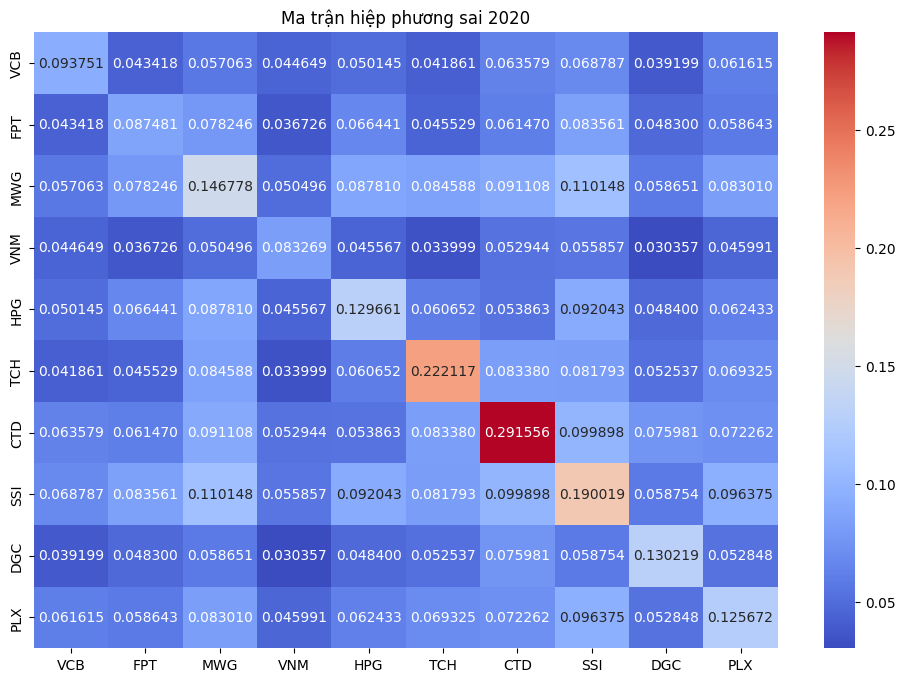

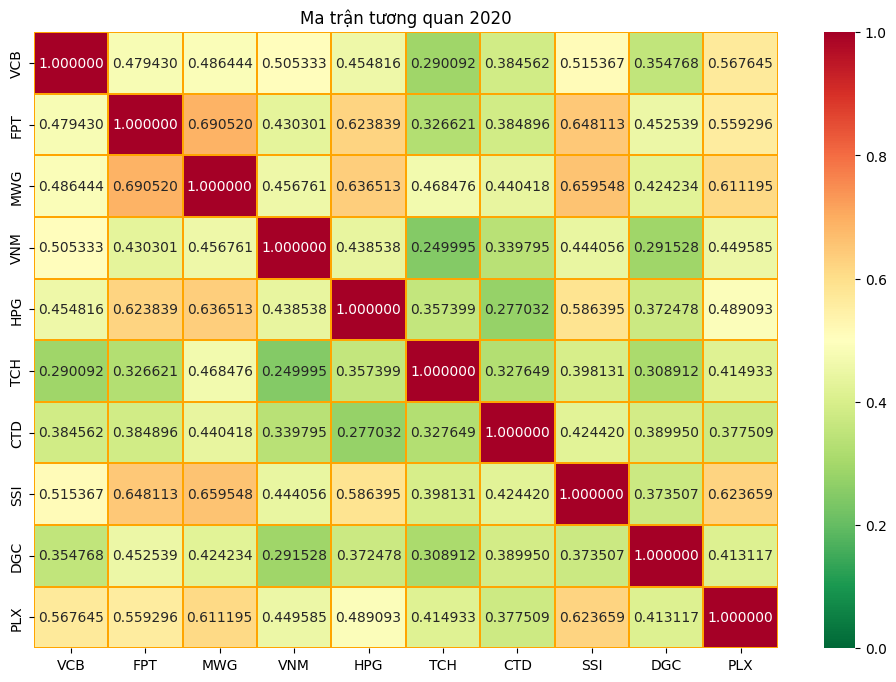

In [45]:
#Đầu vào Markowitz
data_2020 = adj_close_df.loc['2020-01-01':'2020-12-31']
#Lợi suất theo ngày
daily_return = data_2020.pct_change().dropna()

#Lợi suất kì vọng năm (252 ngày giao dịch)

annual_return = daily_return.mean()*252
print ((annual_return*100).round(2))

annual_cov_2020 = daily_return.cov()*252

annual_corr_2020 = daily_return.corr()

plt.figure(figsize=(12,8))
sns.heatmap(annual_cov_2020,annot=True,cmap='coolwarm',fmt='.6f')
plt.title('Ma trận hiệp phương sai 2020')
plt.figure(figsize=(12,8))
sns.heatmap(annual_corr_2020,annot=True,cmap='RdYlGn_r',fmt='.6f',vmin=0, vmax=1,center=0.5,linewidths=.1,linecolor='orange')
plt.title('Ma trận tương quan 2020')
plt.show